<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Risk_Adjusted_Reward_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns # For distribution plots
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
# --- CONFIGURATION ---
TICKER = "BTC-USD" # Let's use Crypto for high volatility/intensity
START = "2018-01-01"
END = "2024-01-01"
WINDOW_SIZE = 30
FEE = 0.001 # 0.1% Fee (Spread + Commission)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def get_data(ticker):
    print(f"⬇️ Downloading High-Vol Data for {ticker}...")
    df = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # Fill & Clean
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    # 1. Log Returns (Better for ML than simple %)
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

    # 2. ATR (Volatility Indicator)
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df['ATR'] = true_range.rolling(14).mean() / df['Close'] # Normalized ATR

    # 3. RSI
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-7)
    df['RSI'] = 100 - (100 / (1 + rs))

    df.dropna(inplace=True)
    return df

df = get_data(TICKER)
print(f"✅ Data Ready: {len(df)} candles.")

⬇️ Downloading High-Vol Data for BTC-USD...


/tmp/ipython-input-655203135.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


✅ Data Ready: 2178 candles.


In [4]:
class AdvancedEnv(gym.Env):
    def __init__(self, df, reward_func):
        super(AdvancedEnv, self).__init__()
        self.df = df
        self.reward_func = reward_func
        self.action_space = spaces.Discrete(3)
        # Obs: [Log_Ret, ATR, RSI, Position_Flag]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 4), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = 10000.0
        self.shares = 0.0
        self.net_worth = 10000.0
        self.prev_net_worth = 10000.0
        self.history = [] # Tracks returns for reward calc
        return self._get_obs(), {}

    def _get_obs(self):
        # Window of features
        frame = self.df.iloc[self.current_step-WINDOW_SIZE : self.current_step]
        # Features: Log_Ret, ATR, RSI
        obs = frame[['Log_Ret', 'ATR', 'RSI']].values

        # Add Position Flag (Are we currently holding?)
        # 1.0 if holding, 0.0 if cash
        pos_flag = np.full((WINDOW_SIZE, 1), 1.0 if self.shares > 0 else 0.0)

        obs = np.hstack((obs, pos_flag))
        return obs.astype(np.float32)

    def step(self, action):
        current_price = float(self.df.iloc[self.current_step]['Close'])

        # 1. Execute Trade (With FEE)
        if action == 1 and self.balance > 0: # Buy
            cost = self.balance * (1 - FEE) # Fee deducted
            self.shares = cost / current_price
            self.balance = 0

        elif action == 2 and self.shares > 0: # Sell
            revenue = self.shares * current_price * (1 - FEE) # Fee deducted
            self.balance = revenue
            self.shares = 0

        self.current_step += 1

        # 2. Update Worth
        next_price = float(self.df.iloc[self.current_step]['Close'])
        self.net_worth = self.balance + (self.shares * next_price)

        # 3. Calculate Step Return
        step_ret = (self.net_worth - self.prev_net_worth) / self.prev_net_worth
        self.history.append(step_ret)
        self.prev_net_worth = self.net_worth

        # 4. Custom Reward
        reward = self.reward_func(self.history, step_ret)

        terminated = self.net_worth < 5000 # Bust
        truncated = self.current_step >= len(self.df) - 5

        return self._get_obs(), reward, terminated, truncated, {'net_worth': self.net_worth}

In [5]:
# 1. The "Kelly" (Logarithmic Utility)
# Mathematically optimal for long-term growth. Penalizes high variance naturally.
# Reward = log(1 + r)
def reward_log_utility(history, step_ret):
    # Clamp to avoid log(<=0) errors
    safe_ret = max(step_ret, -0.99)
    return np.log(1 + safe_ret) * 100 # Scale up for stability

In [6]:
# 2. The "Penalized" (Return - Lambda * Variance)
# Explicitly hates volatility.
# Reward = Return - (0.5 * Variance_of_last_30_days)
def reward_vol_penalty(history, step_ret):
    if len(history) < 30: return step_ret

    window = np.array(history[-30:])
    vol = window.std()

    # Lambda = 2.0 (High dislike of risk)
    return (step_ret - (2.0 * vol)) * 100

In [7]:
# 3. The "Calmar" (Return / Max Drawdown)
# Hates crashing. If DD increases, massive penalty.
def reward_calmar(history, step_ret):
    if len(history) < 30: return step_ret

    # Calculate Max DD in recent window
    window = np.array(history[-30:])
    cum = (1+window).cumprod()
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    max_dd = abs(dd.min())

    # Reward is return penalized by the depth of the hole we are in
    return (step_ret - max_dd) * 100

In [8]:
class PPOAgent:
    def __init__(self, input_dim, action_dim):
        self.gamma = 0.99
        self.clip_ratio = 0.2
        self.K_epochs = 3

        # Initialize networks (Force them to float32 explicitly)
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, action_dim), nn.Softmax(dim=-1)
        ).float().to(DEVICE)

        self.critic = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 1)
        ).float().to(DEVICE)

        self.optimizer = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=0.0003)
        self.reset_memory()

    def reset_memory(self):
        self.states, self.actions, self.logprobs, self.rewards, self.dones = [], [], [], [], []

    def select_action(self, state):
        # Force input to float32
        state = torch.FloatTensor(state).float().flatten().unsqueeze(0).to(DEVICE)
        dist = Categorical(self.actor(state))
        action = dist.sample()
        return action.item(), dist.log_prob(action).item()

    def record(self, s, a, lp, r, d):
        # Force state to float32 immediately upon recording
        self.states.append(torch.tensor(s, dtype=torch.float32).flatten())
        self.actions.append(torch.tensor(a))
        self.logprobs.append(torch.tensor(lp))
        self.rewards.append(r)
        self.dones.append(d)

    def learn(self):
        if not self.states: return

        # 1. Convert lists to Tensors (STRICTLY FLOAT32)
        # Note: torch.stack expects tensors of same type
        states = torch.stack(self.states).to(DEVICE)
        actions = torch.stack(self.actions).to(DEVICE)
        old_logprobs = torch.stack(self.logprobs).to(DEVICE)

        # 2. Calculate Returns (Monte Carlo)
        returns = []
        discounted_sum = 0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.dones)):
            if is_terminal: discounted_sum = 0
            discounted_sum = reward + (0.99 * discounted_sum)
            returns.insert(0, discounted_sum)

        # --- CRITICAL FIX: Force Returns to Float32 ---
        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)

        # Normalize Returns (Safety)
        if returns.std() > 1e-5:
            returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        else:
            returns = returns - returns.mean()

        # 3. Update Loop
        for _ in range(self.K_epochs):
            # Evaluate (Actor & Critic are float32, so inputs must be too)
            probs = self.actor(states)
            dist = Categorical(probs)
            new_logprobs = dist.log_prob(actions)
            entropy = dist.entropy().mean()

            # Critic Value
            state_values = self.critic(states).squeeze()

            # Ratios & Advantages
            ratio = torch.exp(new_logprobs - old_logprobs)

            # Ensure subtraction is float32 - float32
            advantages = returns - state_values.detach()

            # Loss Calculation
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-self.clip_ratio, 1+self.clip_ratio) * advantages

            loss = -torch.min(surr1, surr2) + 0.5 * nn.MSELoss()(state_values, returns) - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.mean().backward()

            # Gradient Clipping (Prevents explosion)
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)

            self.optimizer.step()

        self.reset_memory()

In [10]:
# --- CORRECTED BLOCK 5: INTENSE TRAINING LOOP ---

experiments = {
    "Log Utility (Kelly)": reward_log_utility,
    "Vol Penalty (Risk Averse)": reward_vol_penalty,
    "Calmar (Anti-Crash)": reward_calmar
}

results = {}
returns_dist = {}

print(f"🔥 Starting INTENSE Training on {DEVICE}...")

for name, func in experiments.items():
    print(f"\n🧠 Training Agent: {name}...")

    # 1. SETUP
    env = AdvancedEnv(df, reward_func=func)

    # --- THE FIX IS HERE ---
    # We ask the env for the correct shape instead of hardcoding * 5
    obs_shape = env.observation_space.shape
    input_dim = obs_shape[0] * obs_shape[1] # e.g., 30 * 4 = 120

    agent = PPOAgent(input_dim=input_dim, action_dim=3)

    # 2. TRAIN (30 Episodes)
    for ep in range(30):
        s, _ = env.reset()
        done = False
        while not done:
            # Force Float32
            s = s.astype(np.float32)

            a, lp = agent.select_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            # Record
            agent.record(s, a, lp, r, done)
            s = ns

            if env.current_step % 2048 == 0:
                agent.learn()

    # 3. AUDIT (Deterministic)
    print(f"   -> Running Audit...")
    audit_env = AdvancedEnv(df, reward_func=func)
    s, _ = audit_env.reset()
    done = False
    curve = []

    while not done:
        with torch.no_grad():
            # Force Float32 and correct shape
            s_val = s.astype(np.float32)
            s_t = torch.FloatTensor(s_val).flatten().unsqueeze(0).to(DEVICE)

            action = torch.argmax(agent.actor(s_t)).item()

        s, _, term, trunc, info = audit_env.step(action)
        done = term or trunc
        curve.append(info['net_worth'])

    results[name] = curve

print("✅ Advanced Experiments Complete.")

🔥 Starting INTENSE Training on cpu...

🧠 Training Agent: Log Utility (Kelly)...
   -> Running Audit...

🧠 Training Agent: Vol Penalty (Risk Averse)...
   -> Running Audit...

🧠 Training Agent: Calmar (Anti-Crash)...
   -> Running Audit...
✅ Advanced Experiments Complete.


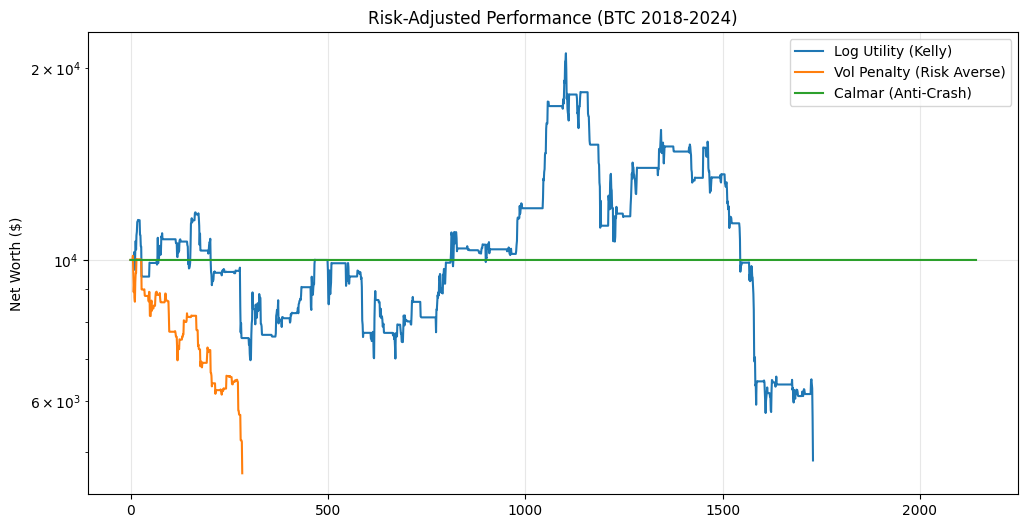

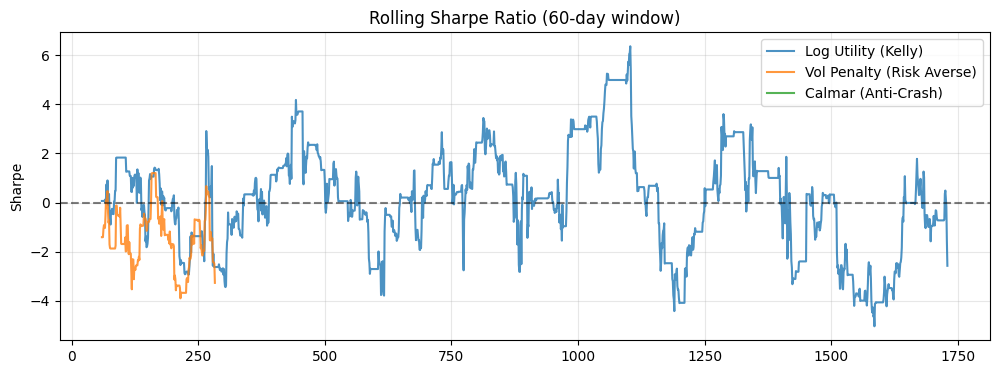

/tmp/ipython-input-2877422525.py:33: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(rets, label=name, clip=(-0.1, 0.1), fill=True, alpha=0.1)


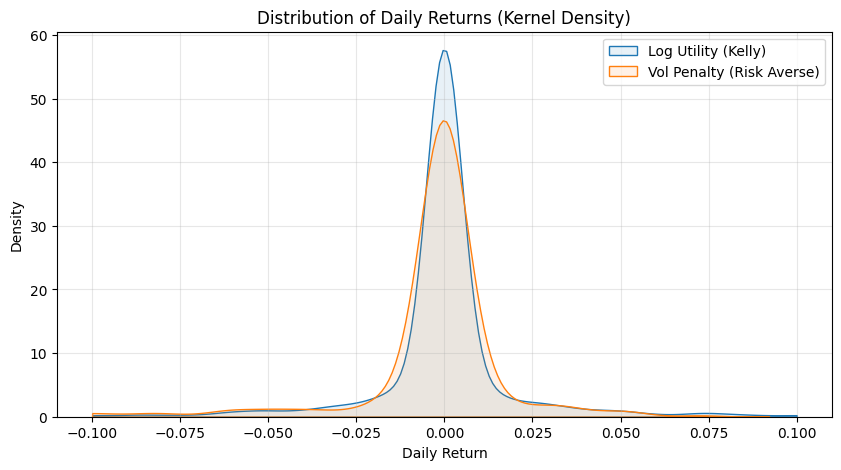

In [11]:
# 1. Equity Curves
plt.figure(figsize=(12, 6))
for name, curve in results.items():
    plt.plot(curve, label=name)
plt.title("Risk-Adjusted Performance (BTC 2018-2024)")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.yscale('log') # Log scale is crucial for Crypto
plt.grid(True, alpha=0.3)
plt.show()

# 2. Rolling Sharpe Ratio (The "Consistency" Test)
plt.figure(figsize=(12, 4))
window = 60 # 2-month rolling window
for name, curve in results.items():
    series = pd.Series(curve)
    rets = series.pct_change().dropna()
    # Rolling Mean / Rolling Std * Sqrt(252)
    rolling_sharpe = (rets.rolling(window).mean() / rets.rolling(window).std()) * np.sqrt(252)
    plt.plot(rolling_sharpe, label=name, linewidth=1.5, alpha=0.8)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title(f"Rolling Sharpe Ratio ({window}-day window)")
plt.ylabel("Sharpe")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Return Distribution (Fat Tails Check)
plt.figure(figsize=(10, 5))
for name, curve in results.items():
    rets = pd.Series(curve).pct_change().dropna()
    sns.kdeplot(rets, label=name, clip=(-0.1, 0.1), fill=True, alpha=0.1)

plt.title("Distribution of Daily Returns (Kernel Density)")
plt.xlabel("Daily Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# --- BLOCK 7: METRICS TABLE ---
final_metrics = []

for name, curve in results.items():
    strat = pd.Series(curve)
    returns = strat.pct_change().dropna()

    # 1. Total Return & CAGR
    total_ret = (strat.iloc[-1] / strat.iloc[0]) - 1
    # Assuming Crypto trades 365 days a year (unlike stocks 252)
    cagr = (strat.iloc[-1] / strat.iloc[0]) ** (365/len(strat)) - 1

    # 2. Volatility
    vol = returns.std() * np.sqrt(365)

    # 3. Sharpe Ratio (Risk-Free Rate assumed 0 for simplicity)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(365) if vol > 0 else 0

    # 4. Sortino Ratio (Only punishes bad volatility)
    neg_ret = returns[returns < 0]
    downside_std = neg_ret.std() * np.sqrt(365) if len(neg_ret) > 0 else 1.0
    sortino = (returns.mean() * 365) / downside_std if downside_std > 0 else 0

    # 5. Max Drawdown (The "Pain" metric)
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    dd = (cum_ret - peak) / peak
    max_dd = dd.min()

    final_metrics.append({
        "Strategy": name,
        "Total Return": f"{total_ret*100:.1f}%",
        "CAGR": f"{cagr*100:.1f}%",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Max Drawdown": f"{max_dd*100:.1f}%",
        "Volatility": f"{vol*100:.1f}%"
    })

# --- DISPLAY ---
print("\n" + "="*80)
print(f"📊 ADVANCED RISK-ADJUSTED SHOWDOWN ({TICKER})")
print("="*80)
metrics_df = pd.DataFrame(final_metrics)
print(metrics_df.to_string(index=False))
print("="*80)


📊 ADVANCED RISK-ADJUSTED SHOWDOWN (BTC-USD)
                 Strategy Total Return   CAGR Sharpe Sortino Max Drawdown Volatility
      Log Utility (Kelly)       -51.5% -14.2%  -0.14   -0.12       -77.0%      42.9%
Vol Penalty (Risk Averse)       -53.7% -62.8%  -2.36   -1.83       -54.4%      38.7%
      Calmar (Anti-Crash)         0.0%   0.0%   0.00    0.00         0.0%       0.0%
